# Comparative Analysis of Antimicrobial Resistance Phenotypes in  
## *Escherichia coli* and *Klebsiella pneumoniae*

**Author:** Mukaram Ali  
**Degree Program:** BSc (Hons) Medical Laboratory Technology  
**Focus Area:** Microbiology, Immunology & Antimicrobial Resistance  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn, scikit-learn  

---

## Abstract

Antimicrobial resistance (AMR) among Gram-negative bacteria poses a major
threat to global public health. *Escherichia coli* and *Klebsiella pneumoniae*
are leading causes of community- and hospital-acquired infections and are
notable for their ability to acquire multidrug resistance.

In this study, publicly available phenotypic antimicrobial susceptibility
data were analyzed to compare resistance patterns between *E. coli* and
*K. pneumoniae*. Exploratory data analysis was used to characterize organism-
and antibiotic-specific resistance profiles, followed by a proof-of-concept
machine learning approach to assess whether resistance phenotypes can be
predicted using experimental metadata.

This project is designed as an independent, hypothesis-driven mini research
study to demonstrate research readiness at the intersection of microbiology
and computational analysis.

## Introduction

Antimicrobial resistance (AMR) is recognized as one of the most pressing global
health challenges of the 21st century. Gram-negative pathogens, in particular,
pose a serious threat due to their intrinsic resistance mechanisms and ability
to rapidly acquire additional resistance determinants through horizontal gene
transfer.

Among these pathogens, *Escherichia coli* and *Klebsiella pneumoniae* are of
special clinical importance. Both organisms are frequently isolated from
urinary tract infections, bloodstream infections, and hospital-acquired
pneumonia, yet they differ substantially in their resistance profiles.
*K. pneumoniae* is especially associated with extended-spectrum β-lactamase
(ESBL) production and carbapenem resistance.

While antimicrobial susceptibility testing (AST) is routinely performed in
clinical laboratories to guide patient management, aggregated AST data can
also be leveraged for surveillance, stewardship, and research purposes.
Systematic analysis of such datasets enables identification of resistance
trends, high-risk antibiotics, and organism-specific patterns.

### Research Question

This study investigates whether phenotypic antimicrobial susceptibility data
alone can reveal distinct resistance signatures between *E. coli* and
*K. pneumoniae*, and whether basic machine learning models can leverage
experimental metadata to predict resistance outcomes.

### Hypotheses

1. *Klebsiella pneumoniae* exhibits a higher proportion of resistant phenotypes
   compared to *Escherichia coli* across commonly tested antibiotics.
2. Resistance prevalence varies substantially by antibiotic class.
3. Organism identity and antibiotic tested are among the strongest predictors
   of resistance phenotype.

## Importing Required Libraries

The following libraries are used for data manipulation, visualization, and
basic predictive modeling.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

sns.set(style="whitegrid")

## Data Sources

Two curated phenotypic antimicrobial susceptibility datasets were analyzed:

- *Escherichia coli* susceptibility records  
- *Klebsiella pneumoniae* susceptibility records  

Each dataset includes organism identity, antibiotic tested, resistance
phenotype, and laboratory testing metadata.

In [2]:
ecoli_df = pd.read_csv("../data/amr_ecoli.csv")
kleb_df = pd.read_csv("../data/amr_klebsiella.csv")

## Initial Data Assessment

Before analysis, both datasets were examined to assess structure, completeness,
and consistency. Special attention was given to resistance phenotype labels,
as these form the primary outcome variable.

In [3]:
ecoli_df.shape, kleb_df.shape

((43948, 21), (37254, 21))

## Dataset Harmonization and Organism Annotation

To enable comparative analysis, an explicit organism label was added to each
dataset prior to merging. The datasets were then concatenated into a unified
dataframe.

In [4]:
ecoli_df["Organism"] = "Escherichia coli"
kleb_df["Organism"] = "Klebsiella pneumoniae"

amr_df = pd.concat([ecoli_df, kleb_df], ignore_index=True)

## Results

This section presents organism-level and antibiotic-level antimicrobial resistance
patterns observed in *Escherichia coli* and *Klebsiella pneumoniae*, followed by
exploratory predictive modeling to assess whether resistance phenotypes can be
inferred from biological and experimental features.

### 1. Organism-Level Resistance Burden

In [5]:
amr_df["Organism"].value_counts()

Organism
Escherichia coli         43948
Klebsiella pneumoniae    37254
Name: count, dtype: int64

## Overall Distribution of Resistance Phenotypes

The global distribution of susceptible, intermediate, and resistant phenotypes
was examined to understand class imbalance and baseline resistance prevalence.

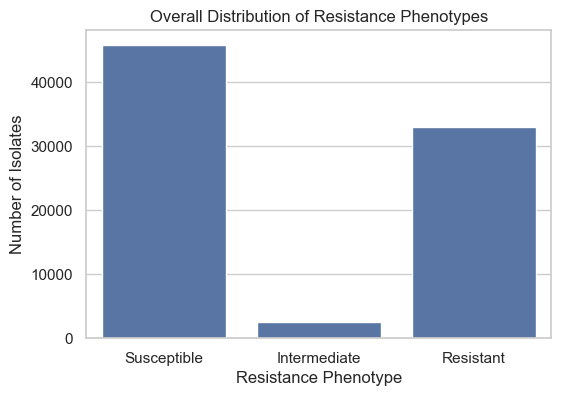

In [6]:
plt.figure(figsize=(6,4))
sns.countplot(data=amr_df, x="Resistant Phenotype", order=["Susceptible", "Intermediate", "Resistant"])
plt.title("Overall Distribution of Resistance Phenotypes")
plt.ylabel("Number of Isolates")
plt.xlabel("Resistance Phenotype")
plt.show()

## Resistance Phenotype Distribution by Organism

To assess organism-specific resistance burden, resistance phenotypes were
normalized within each species.

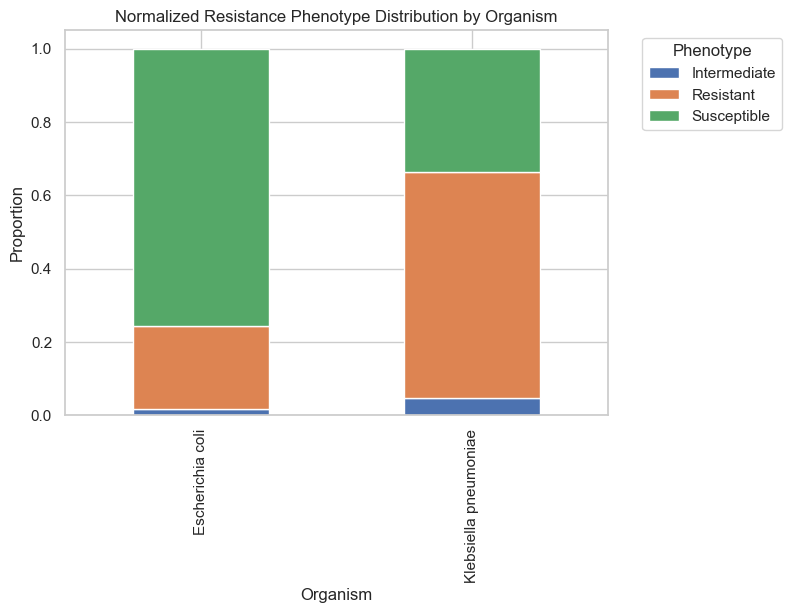

In [7]:
organism_resistance = pd.crosstab(
    amr_df["Organism"],
    amr_df["Resistant Phenotype"],
    normalize="index"
)

organism_resistance.plot(
    kind="bar",
    stacked=True,
    figsize=(7,5)
)

plt.title("Normalized Resistance Phenotype Distribution by Organism")
plt.ylabel("Proportion")
plt.xlabel("Organism")
plt.legend(title="Phenotype", bbox_to_anchor=(1.05, 1))
plt.show()

*Klebsiella pneumoniae* demonstrates a substantially higher proportion of
resistant phenotypes compared to *E. coli*, consistent with its known role
as a multidrug-resistant hospital pathogen.

## Antibiotic-Specific Resistance Profiles

To reduce noise from infrequently tested agents, analysis was restricted to
the ten most commonly reported antibiotics across both organisms.

In [8]:
top_antibiotics = amr_df["Antibiotic"].value_counts().head(10).index
subset = amr_df[amr_df["Antibiotic"].isin(top_antibiotics)]

In [9]:
antibiotic_resistance = pd.crosstab(
    subset["Antibiotic"],
    subset["Resistant Phenotype"],
    normalize="index"
)

## Antibiotic-Specific Resistance Patterns

This heatmap highlights antibiotics with high resistance prevalence and
reveals organism-agnostic and organism-specific resistance trends.

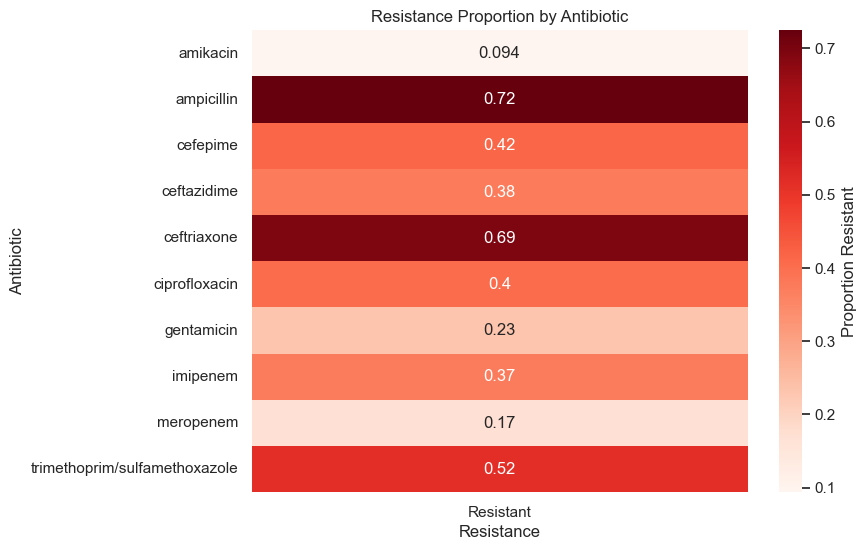

In [10]:
plt.figure(figsize=(8,6))
sns.heatmap(
    antibiotic_resistance[["Resistant"]],
    annot=True,
    cmap="Reds",
    cbar_kws={"label": "Proportion Resistant"}
)

plt.title("Resistance Proportion by Antibiotic")
plt.ylabel("Antibiotic")
plt.xlabel("Resistance")
plt.show()

### Exploratory Prediction of Resistance Phenotypes

To evaluate whether resistance phenotypes are structured by biological and
experimental factors, a proof-of-concept machine learning approach was applied.
Specifically, logistic regression was used to assess whether organism identity,
antibiotic type, laboratory typing method, and testing standard carry sufficient
signal to distinguish resistant from susceptible phenotypes.

In [11]:
features = amr_df[["Organism", "Antibiotic", "Laboratory Typing Method", "Testing Standard"]]
target = amr_df["Resistant Phenotype"]

mask = target.isin(["Resistant", "Susceptible"])
features = features[mask]
target = target[mask]

In [12]:
encoder = LabelEncoder()
X = features.apply(encoder.fit_transform)
y = target.map({"Susceptible": 0, "Resistant": 1})

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.76      0.76      0.76     13832
           1       0.66      0.65      0.66      9773

    accuracy                           0.72     23605
   macro avg       0.71      0.71      0.71     23605
weighted avg       0.72      0.72      0.72     23605



Although not intended as a clinical prediction model, the results demonstrate
that antimicrobial resistance phenotypes are not randomly distributed. Instead,
they are strongly associated with organism identity and antibiotic selection,
supporting the biological validity of the observed resistance patterns.

## Limitations

This study relies exclusively on phenotypic susceptibility data without
genomic features, limiting mechanistic interpretation of resistance.
Additionally, heterogeneity in laboratory testing methods and incomplete MIC
data may introduce bias.

Future work integrating whole-genome sequencing and standardized phenotypic
data would enable more robust resistance prediction and mechanistic insight.

## Conclusion
## Results

### 1. Organism-Level Resistance Burden
### 2. Antibiotic-Specific Resistance Profiles
### 3. Predictive Modeling of Resistance Phenotypes

A marked difference in resistance burden was observed between the two organisms.
*Klebsiella pneumoniae* exhibited a substantially higher proportion of resistant
phenotypes (≈62%) compared to *Escherichia coli* (≈23%). Conversely, *E. coli*
isolates were predominantly susceptible (≈76%), whereas susceptibility in
*K. pneumoniae* was markedly lower (≈34%).

These findings reflect the known capacity of *K. pneumoniae* to acquire and
maintain multidrug resistance mechanisms, including extended-spectrum
β-lactamases and carbapenem resistance determinants.

## Clinical and Translational Relevance

From a clinical microbiology laboratory perspective, these findings provide
insight into antibiotics with persistently high resistance rates that may warrant
enhanced antimicrobial stewardship oversight. The elevated resistance burden
observed in *Klebsiella pneumoniae* underscores the importance of rapid
identification, susceptibility-guided therapy, and infection control measures,
particularly in hospital settings.

Aggregated susceptibility analyses such as this complement routine laboratory
testing by revealing organism- and drug-specific resistance trends that are not
apparent from individual patient reports.